# Claim Denial Prediction — Full Pipeline (Colab)

All 4 phases plus the unified cross-phase ablation, flattened out of the
`claim-denial-prediction-v2` package structure (`shared/`, `phase1_baseline/`,
`phase2_gbm_shap/`, `phase3_clinicalbert/`, `phase4_rag_agentic/`,
`scripts/`) into one notebook so it runs standalone on a stock Colab CPU
runtime — no local package install, no `sys.path` hacks.

**Deliberately excluded:** Phase 3's Claude zero-shot baseline
(`phase3_clinicalbert/src/llm_baseline.py`), which makes a real Anthropic API
call. Everything else here is local compute only — FAISS and the
Anthropic/OpenAI SDKs are optional in the original project (numpy/mock
fallbacks built in), so nothing in this notebook needs an API key or external
service.

Run cells top to bottom. Section headers match the original file each cell
was ported from, so you can cross-reference back to the repo.

In [1]:
!pip install -q numpy pandas scikit-learn scipy xgboost shap imbalanced-learn matplotlib pyarrow pydantic pydantic-settings

In [2]:
from __future__ import annotations

import pickle
import warnings
from dataclasses import dataclass, field, asdict
from datetime import date, timedelta
from enum import Enum
from pathlib import Path
from typing import Any, Optional

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pydantic import BaseModel, ConfigDict, Field, field_validator
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from scipy.stats import spearmanr, ks_2samp
import shap

try:
    import faiss
except ImportError:  # no faiss wheel -> NumPy fallback (same as the repo)
    faiss = None

%matplotlib inline

# One artifacts tree for the whole notebook (each phase file originally wrote
# to its own package-relative artifacts/ dir; flattened here into subfolders).
ARTIFACT_DIR = Path("artifacts"); ARTIFACT_DIR.mkdir(exist_ok=True)
PHASE1_DIR = ARTIFACT_DIR / "phase1"; PHASE1_DIR.mkdir(parents=True, exist_ok=True)
PHASE2_DIR = ARTIFACT_DIR / "phase2"; PHASE2_DIR.mkdir(parents=True, exist_ok=True)
PHASE3_DIR = ARTIFACT_DIR / "phase3"; PHASE3_DIR.mkdir(parents=True, exist_ok=True)
PHASE4_DIR = ARTIFACT_DIR / "phase4"; PHASE4_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PHASE4_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

## `shared/schemas/claim.py` — canonical claim record

One typed schema every phase reads/writes, so Phase 4's retrieval index can't
silently drift out of sync with what Phase 1/2 trained on.

In [3]:
class InsuranceType(str, Enum):
    MEDICARE = "medicare"
    MEDICAID = "medicaid"
    PRIVATE = "private"
    SELF_PAY = "self_pay"
    OTHER = "other"


class ClaimRecord(BaseModel):
    """
    One medical claim. Structured fields map to Phase 1/2's Kaggle dataset;
    `clinical_note_text` is populated only for records that also exist in
    MIMIC-IV-Note (Phase 3), and stays None otherwise.
    """

    model_config = ConfigDict(use_enum_values=True)

    claim_id: str
    provider_id: str
    patient_id: Optional[str] = None  # None for fully de-identified sources

    icd10_code: str = Field(..., description="Primary diagnosis code")
    cpt_code: str = Field(..., description="Primary procedure code")
    insurance_type: InsuranceType
    billed_amount: float = Field(..., ge=0)

    service_date: date
    submission_date: date

    reason_code: Optional[str] = None
    clinical_note_text: Optional[str] = Field(
        default=None,
        description="Discharge summary / physician note, Phase 3+ only. "
        "Never populate from raw MIMIC-IV-Note without CITI-credentialed access.",
    )

    denied: Optional[bool] = Field(
        default=None, description="Label. None at inference time."
    )

    @field_validator("submission_date")
    @classmethod
    def submission_after_service(cls, v: date, info):
        service_date = info.data.get("service_date")
        if service_date and v < service_date:
            raise ValueError("submission_date cannot precede service_date")
        return v

## `shared/utils/eval.py` — shared evaluation harness

The single place AUROC/F1/precision/recall are computed, so every phase's
numbers are directly comparable in the cross-phase ablation. `log_to_mlflow`
and the `settings`-based MLflow config are dropped here (unused by any phase
script — MLflow logging was never wired into the run scripts, just available
as an opt-in).

In [4]:
@dataclass
class EvalResult:
    phase: str
    model_name: str
    auroc: float
    f1: float
    precision: float
    recall: float
    n_samples: int

    def as_dict(self) -> dict[str, Any]:
        return asdict(self)


def evaluate(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    phase: str,
    model_name: str,
    threshold: float = 0.5,
) -> EvalResult:
    y_pred = (y_prob >= threshold).astype(int)
    return EvalResult(
        phase=phase,
        model_name=model_name,
        auroc=float(roc_auc_score(y_true, y_prob)),
        f1=float(f1_score(y_true, y_pred, zero_division=0)),
        precision=float(precision_score(y_true, y_pred, zero_division=0)),
        recall=float(recall_score(y_true, y_pred, zero_division=0)),
        n_samples=len(y_true),
    )


def _percentiles(values: list[float], ci: float) -> list[float]:
    lo, hi = (1 - ci) / 2 * 100, (1 + ci) / 2 * 100
    return [float(np.percentile(values, lo)), float(np.percentile(values, hi))]


def bootstrap_auroc_lift(
    y_true: np.ndarray,
    p_base: np.ndarray,
    p_better: np.ndarray,
    n_boot: int = 2000,
    seed: int = 0,
    ci: float = 0.95,
) -> dict[str, Any]:
    """PAIRED percentile bootstrap for an AUROC lift (better - base). Resamples
    test rows with replacement and scores BOTH models on the SAME resample each
    iteration (their errors are correlated, so pairing gives the correct,
    tighter CI on the difference than two independent CIs would). Returns each
    model's CI, the lift CI, and a one-sided bootstrap p-value = fraction of
    resamples where the lift is <= 0."""
    y_true = np.asarray(y_true)
    p_base = np.asarray(p_base)
    p_better = np.asarray(p_better)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    base, better, lift = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        if yt.min() == yt.max():  # need both classes to define AUROC
            continue
        a = roc_auc_score(yt, p_base[idx])
        b = roc_auc_score(yt, p_better[idx])
        base.append(a)
        better.append(b)
        lift.append(b - a)
    lift_arr = np.asarray(lift)
    return {
        "auroc_base": float(roc_auc_score(y_true, p_base)),
        "auroc_better": float(roc_auc_score(y_true, p_better)),
        "auroc_base_ci": _percentiles(base, ci),
        "auroc_better_ci": _percentiles(better, ci),
        "lift_point": float(roc_auc_score(y_true, p_better) - roc_auc_score(y_true, p_base)),
        "lift_mean": float(lift_arr.mean()),
        "lift_ci": _percentiles(lift_arr, ci),
        "p_value_one_sided": float((lift_arr <= 0).mean()),
        "n_boot": int(len(lift_arr)),
    }

## `phase4_rag_agentic/src/labeling.py` — fault-injection denial labeling

Explicit, documented, log-additive risk model over named denial drivers
(missing prior auth, medical-necessity mismatch, out-of-network, untimely
filing, billing anomaly, undocumented necessity). The intercept is
auto-calibrated by bisection so realized prevalence lands on the target
(default 0.19, CMS ACA 2024) regardless of the sampled feature mix.

In [5]:
DRIVER_WEIGHTS = {
    "untimely_filing": 3.2,        # submitted after the payer's filing window
    "missing_prior_auth": 2.6,     # procedure required prior auth, none obtained
    "medical_necessity": 2.0,      # diagnosis not covered for this procedure (code-based)
    "undocumented_necessity": 1.6, # necessity not JUSTIFIED in the note (text-only signal)
    "out_of_network": 1.4,         # provider out-of-network for the payer
    "billing_anomaly": 1.2,        # billed amount far above the procedure norm
}
PAYER_RESIDUAL = {
    "medicare": 0.0, "medicaid": 0.35, "private": -0.1,
    "self_pay": 0.5, "other": 0.1,
}

REASON_TEXT = {
    "untimely_filing": "CO-29 Untimely filing: submitted after payer window",
    "missing_prior_auth": "CO-197 Precertification/authorization absent",
    "medical_necessity": "CO-50 Non-covered: not deemed medically necessary",
    "undocumented_necessity": "CO-50/N115 Medical necessity not established by documentation",
    "out_of_network": "CO-242 Services not provided by network provider",
    "billing_anomaly": "CO-45 Charge exceeds fee schedule / documentation",
    "baseline": "No dominant driver (baseline payer risk)",
}


@dataclass
class LabelingResult:
    frame: pd.DataFrame          # input frame + denied / true_denial_prob / reason_code
    intercept: float             # calibrated intercept
    realized_prevalence: float
    driver_prevalence: dict      # fraction of claims tripping each driver


def _driver_contributions(frame: pd.DataFrame) -> pd.DataFrame:
    """Per-claim log-odds contribution from each named denial driver."""
    late = (frame["_filing_days"] > frame["_filing_window"]).astype(float)
    no_pa = (frame["_prior_auth_required"] & ~frame["_prior_auth_obtained"]).astype(float)
    necessity = (~frame["_necessity_ok"]).astype(float)
    undocumented = (~frame["_necessity_documented"]).astype(float)
    oon = (~frame["_in_network"]).astype(float)
    anomaly = np.clip(frame["_amount_ratio"] - 1.6, 0, None)

    return pd.DataFrame({
        "untimely_filing": DRIVER_WEIGHTS["untimely_filing"] * late,
        "missing_prior_auth": DRIVER_WEIGHTS["missing_prior_auth"] * no_pa,
        "medical_necessity": DRIVER_WEIGHTS["medical_necessity"] * necessity,
        "undocumented_necessity": DRIVER_WEIGHTS["undocumented_necessity"] * undocumented,
        "out_of_network": DRIVER_WEIGHTS["out_of_network"] * oon,
        "billing_anomaly": DRIVER_WEIGHTS["billing_anomaly"] * anomaly,
    }, index=frame.index)


def _sigmoid(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-z))


def _calibrate_intercept(base_logodds: np.ndarray, target: float,
                         tol: float = 1e-4) -> float:
    """Bisection: find intercept b so mean(sigmoid(base + b)) == target."""
    lo, hi = -20.0, 20.0
    for _ in range(200):
        mid = (lo + hi) / 2
        prev = _sigmoid(base_logodds + mid).mean()
        if abs(prev - target) < tol:
            return mid
        if prev < target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2


def label_claims(frame: pd.DataFrame, target_prevalence: float = 0.19,
                 label_noise: float = 0.0, seed: int = 42) -> LabelingResult:
    """Inject denial labels. Returns the frame with three added columns:
    true_denial_prob (clean signal), denied (possibly noisy injected label),
    reason_code (dominant denial driver for denied claims)."""
    rng = np.random.default_rng(seed)
    contrib = _driver_contributions(frame)
    payer_resid = frame["insurance_type"].map(PAYER_RESIDUAL).to_numpy()
    prov_resid = frame["_provider_propensity"].to_numpy()

    base = contrib.sum(axis=1).to_numpy() + payer_resid + prov_resid
    intercept = _calibrate_intercept(base, target_prevalence)
    prob = _sigmoid(base + intercept)

    clean_label = (rng.random(len(frame)) < prob).astype(int)
    if label_noise > 0:
        flip = rng.random(len(frame)) < label_noise
        noisy = np.where(flip, 1 - clean_label, clean_label)
    else:
        noisy = clean_label

    dominant = contrib.idxmax(axis=1)
    any_driver = contrib.to_numpy().max(axis=1) > 0
    reason = np.where(any_driver, dominant, "baseline")

    out = frame.copy()
    out["true_denial_prob"] = prob
    out["denied"] = noisy
    out["reason_code"] = [REASON_TEXT[r] if d else None
                          for r, d in zip(reason, noisy)]

    driver_prev = {c: float((contrib[c] > 0).mean()) for c in contrib.columns}
    return LabelingResult(
        frame=out,
        intercept=float(intercept),
        realized_prevalence=float(noisy.mean()),
        driver_prevalence=driver_prev,
    )

## `phase4_rag_agentic/src/data_gen.py` — controlled synthetic claim generator

Generates correlated, realistic claims (billed amount depends on procedure,
prior-auth requirement depends on procedure, network status depends on payer,
filing delay depends on payer) plus a synthetic `clinical_note` per claim. The
note is generated from a latent `_necessity_documented` flag and NEVER from
the denial label — that's what lets Phase 3 measure real text signal instead
of a shortcut.

In [6]:
ICD10 = {
    "chronic": ["E11.9", "I10", "E78.5", "N18.3"],          # diabetes, HTN, lipids, CKD
    "respiratory": ["J45.909", "J44.9", "J20.9"],            # asthma, COPD, bronchitis
    "musculoskeletal": ["M54.5", "M25.561", "M17.11"],       # low-back, knee pain, OA
    "mental_health": ["F41.1", "F32.9", "F43.23"],           # anxiety, depression, adj.
    "gastro": ["K21.9", "K57.30", "K80.20"],                 # GERD, diverticulosis, gallstones
}
ICD_CATEGORIES = list(ICD10)


@dataclass(frozen=True)
class Procedure:
    cpt: str
    label: str
    base_cost: float
    prior_auth: bool
    covered_for: tuple[str, ...]


PROCEDURES = [
    Procedure("99213", "Office visit, low", 120, False, tuple(ICD_CATEGORIES)),
    Procedure("99214", "Office visit, moderate", 200, False, tuple(ICD_CATEGORIES)),
    Procedure("93000", "ECG", 180, False, ("chronic",)),
    Procedure("80053", "Metabolic panel", 90, False, ("chronic", "gastro")),
    Procedure("70450", "CT head w/o contrast", 1200, True, ("mental_health", "respiratory")),
    Procedure("45378", "Colonoscopy", 2100, True, ("gastro",)),
    Procedure("20610", "Major joint injection", 350, True, ("musculoskeletal",)),
    Procedure("97110", "Physical therapy", 110, False, ("musculoskeletal",)),
    Procedure("90837", "Psychotherapy, 60min", 190, True, ("mental_health",)),
    Procedure("71046", "Chest X-ray", 260, False, ("respiratory",)),
]
PROCEDURE_BY_CPT = {p.cpt: p for p in PROCEDURES}

INSURANCE_TYPES = [
    InsuranceType.MEDICARE.value,
    InsuranceType.MEDICAID.value,
    InsuranceType.PRIVATE.value,
    InsuranceType.SELF_PAY.value,
    InsuranceType.OTHER.value,
]
INSURANCE_WEIGHTS = np.array([0.30, 0.20, 0.38, 0.07, 0.05])

FILING_WINDOW_DAYS = {
    "medicare": 365,
    "medicaid": 95,
    "private": 180,
    "self_pay": 10_000,   # effectively no payer filing rule
    "other": 180,
}

N_PROVIDERS = 60

_DX_PHRASES = {
    "chronic": ["type 2 diabetes mellitus", "essential hypertension",
                "hyperlipidemia", "stage 3 chronic kidney disease"],
    "respiratory": ["an asthma exacerbation", "chronic obstructive pulmonary disease",
                    "acute bronchitis"],
    "musculoskeletal": ["chronic low back pain", "knee osteoarthritis",
                        "persistent joint pain"],
    "mental_health": ["generalized anxiety disorder", "major depressive disorder",
                      "an adjustment disorder"],
    "gastro": ["gastroesophageal reflux disease", "diverticulosis", "cholelithiasis"],
}
_SEX = ["male", "female"]
_FILLER = [
    "Vital signs were stable and the examination was unremarkable aside from the presenting complaint.",
    "Past medical history was reviewed and home medications were reconciled.",
    "The patient tolerated the encounter well and appropriate follow-up was arranged.",
    "Relevant laboratory studies were reviewed and were within expected limits.",
]
_JUSTIFICATION = [
    "Conservative management including NSAIDs and physical therapy was trialed for six weeks without adequate relief.",
    "Symptoms have progressed despite first-line therapy, and prior imaging supports the need for this intervention.",
    "The patient meets published guideline criteria; earlier conservative measures failed to control symptoms.",
    "Documentation establishes medical necessity: prior treatments were exhausted and the condition continues to worsen.",
]
_NO_JUSTIFICATION = [
    "The procedure was performed during today's encounter.",
    "The service was carried out as scheduled.",
    "No prior conservative therapy is documented in the available record.",
    "Indication was noted per the ordering provider; further justification was not recorded.",
]


def _compose_note(aux, icd_cat: str, proc_label: str, documented: bool) -> str:
    """Build one synthetic clinical note. `aux` is a dedicated RNG stream so note
    text does not perturb the structured-claim random draws."""
    age = int(aux.integers(19, 89))
    sex = _SEX[aux.integers(2)]
    dx_list = _DX_PHRASES[icd_cat]
    dx = dx_list[aux.integers(len(dx_list))]
    verb = ["performed", "ordered", "completed"][aux.integers(3)]
    opening = f"{age}-year-old {sex} evaluated for {dx}."
    proc_line = f"{proc_label} was {verb}."
    if documented:
        necessity = _JUSTIFICATION[aux.integers(len(_JUSTIFICATION))]
    else:
        necessity = _NO_JUSTIFICATION[aux.integers(len(_NO_JUSTIFICATION))]
    fi = aux.choice(len(_FILLER), size=2, replace=False)
    parts = [opening, _FILLER[fi[0]], proc_line, necessity, _FILLER[fi[1]]]
    return " ".join(parts)


@dataclass
class GeneratedClaims:
    frame: pd.DataFrame           # observable + latent columns (latent prefixed `_`)
    observable_columns: list[str]
    latent_columns: list[str]


def generate_claims(n: int = 40_000, seed: int = 42,
                    start: date = date(2023, 1, 1),
                    end: date = date(2024, 12, 31)) -> GeneratedClaims:
    """Generate `n` synthetic claims with correlated, realistic structure.
    Latent columns (prefixed `_`) encode the denial drivers and are consumed
    only by labeling; the observable columns are what a billing reviewer (and
    therefore the model and the retriever) actually see."""
    rng = np.random.default_rng(seed)

    provider_ids = [f"prov-{i:03d}" for i in range(N_PROVIDERS)]
    provider_quality = dict(zip(provider_ids, rng.beta(6, 2, size=N_PROVIDERS)))
    provider_network = dict(zip(provider_ids, rng.beta(8, 2, size=N_PROVIDERS)))
    provider_propensity = dict(zip(provider_ids, rng.normal(0.0, 0.9, N_PROVIDERS)))

    span_days = (end - start).days
    rows = []
    aux = np.random.default_rng(seed + 7)
    for i in range(n):
        payer = rng.choice(INSURANCE_TYPES, p=INSURANCE_WEIGHTS)
        icd_cat = rng.choice(ICD_CATEGORIES)
        icd10 = rng.choice(ICD10[icd_cat])
        provider = provider_ids[rng.integers(N_PROVIDERS)]

        compatible = [p for p in PROCEDURES if icd_cat in p.covered_for]
        if compatible and rng.random() < 0.80:
            proc = compatible[rng.integers(len(compatible))]
        else:
            proc = PROCEDURES[rng.integers(len(PROCEDURES))]

        upcoded = rng.random() < 0.08
        mult = rng.lognormal(mean=0.0, sigma=0.25) * (2.2 if upcoded else 1.0)
        billed = round(float(proc.base_cost * mult), 2)

        service = start + timedelta(days=int(rng.integers(0, span_days + 1)))
        base_delay = {"medicaid": 20, "medicare": 40, "private": 30,
                      "self_pay": 25, "other": 30}[payer]
        filing_days = int(max(0, rng.gamma(shape=2.0, scale=base_delay / 2.0)))
        if rng.random() < 0.06:
            filing_days += int(rng.gamma(shape=3.0, scale=120.0))
        submission = service + timedelta(days=filing_days)

        pa_required = proc.prior_auth
        pa_obtained = bool(rng.random() < provider_quality[provider]) if pa_required else True

        in_network = bool(rng.random() < provider_network[provider])

        necessity_ok = icd_cat in proc.covered_for

        necessity_documented = bool(aux.random() < 0.60)
        clinical_note = _compose_note(aux, icd_cat, proc.label, necessity_documented)

        rows.append({
            "claim_id": f"CLM-{i:07d}",
            "provider_id": provider,
            "patient_id": f"PT-{rng.integers(0, n // 3):07d}",
            "icd10_code": icd10,
            "cpt_code": proc.cpt,
            "insurance_type": payer,
            "billed_amount": billed,
            "service_date": service,
            "submission_date": submission,
            "clinical_note": clinical_note,
            "_icd_category": icd_cat,
            "_procedure_base_cost": proc.base_cost,
            "_amount_ratio": billed / proc.base_cost,
            "_filing_days": filing_days,
            "_filing_window": FILING_WINDOW_DAYS[payer],
            "_prior_auth_required": pa_required,
            "_prior_auth_obtained": pa_obtained,
            "_in_network": in_network,
            "_necessity_ok": necessity_ok,
            "_necessity_documented": necessity_documented,
            "_provider_quality": provider_quality[provider],
            "_provider_propensity": provider_propensity[provider],
        })

    frame = pd.DataFrame(rows)
    latent = [c for c in frame.columns if c.startswith("_")]
    observable = [c for c in frame.columns if not c.startswith("_")]
    return GeneratedClaims(frame=frame, observable_columns=observable,
                           latent_columns=latent)


def row_to_claim(row: pd.Series) -> ClaimRecord:
    """Convert one observable row to the shared typed schema."""
    return ClaimRecord(
        claim_id=row["claim_id"],
        provider_id=row["provider_id"],
        patient_id=row.get("patient_id"),
        icd10_code=row["icd10_code"],
        cpt_code=row["cpt_code"],
        insurance_type=row["insurance_type"],
        billed_amount=float(row["billed_amount"]),
        service_date=row["service_date"],
        submission_date=row["submission_date"],
        reason_code=row.get("reason_code") if pd.notna(row.get("reason_code")) else None,
        denied=bool(row["denied"]) if "denied" in row and pd.notna(row["denied"]) else None,
    )


def generate_dataset(n: int = 40_000, seed: int = 42,
                     target_prevalence: float = 0.19,
                     label_noise: float = 0.0) -> pd.DataFrame:
    """Unified entry point for ALL phases: generate correlated claims (with a
    synthetic `clinical_note` per claim) AND inject denial labels in one call,
    so every phase consumes the exact same rows and the cross-phase ablation
    is apples-to-apples by construction."""
    gen = generate_claims(n=n, seed=seed)
    return label_claims(gen.frame, target_prevalence=target_prevalence,
                        label_noise=label_noise, seed=seed).frame

## `phase4_rag_agentic/src/retriever.py` — similarity index over historical claims

FAISS's `IndexFlatIP` is the production backend; a NumPy fallback with
byte-identical query semantics covers machines without a faiss wheel (this
notebook uses whichever is available — `faiss` was not installed above, so
expect `backend == "numpy"` unless you `!pip install faiss-cpu` yourself).

In [7]:
@dataclass
class RetrievedClaim:
    claim: ClaimRecord
    similarity: float


def _l2_normalize(x: np.ndarray) -> np.ndarray:
    """Row-wise L2 normalize; guards zero vectors so cosine == inner product."""
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (x / norms).astype("float32")


class _NumpyBackend:
    """Exact cosine top-k over a stacked matrix of normalized vectors. Same
    search contract as faiss.IndexFlatIP: returns (similarities, indices) with
    -1 padding when fewer than k vectors exist."""

    def __init__(self, dim: int):
        self.dim = dim
        self._mat = np.empty((0, dim), dtype="float32")

    def add(self, normed: np.ndarray) -> None:
        self._mat = np.vstack([self._mat, normed]) if self._mat.size else normed

    def search(self, q: np.ndarray, k: int):
        if self._mat.shape[0] == 0:
            return np.full((q.shape[0], k), -np.inf), np.full((q.shape[0], k), -1)
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            sims = q @ self._mat.T                   # (n_query, n_index)
        k = min(k, sims.shape[1])
        idx = np.argpartition(-sims, k - 1, axis=1)[:, :k]
        order = np.argsort(-np.take_along_axis(sims, idx, axis=1), axis=1)
        idx = np.take_along_axis(idx, order, axis=1)
        top_sims = np.take_along_axis(sims, idx, axis=1)
        return top_sims, idx

    @property
    def ntotal(self) -> int:
        return self._mat.shape[0]


class ClaimRetriever:
    """Wraps a similarity index + a parallel list of ClaimRecords, kept as two
    parallel structures rather than storing metadata inside the index itself."""

    def __init__(self, embedding_dim: int):
        self.embedding_dim = embedding_dim
        if faiss is not None:
            self.index = faiss.IndexFlatIP(embedding_dim)
            self.backend = "faiss"
        else:
            self.index = _NumpyBackend(embedding_dim)
            self.backend = "numpy"
        self._claims: list[ClaimRecord] = []

    def add(self, embeddings: np.ndarray, claims: list[ClaimRecord]) -> None:
        assert embeddings.shape[0] == len(claims)
        assert embeddings.shape[1] == self.embedding_dim
        self.index.add(_l2_normalize(embeddings))
        self._claims.extend(claims)

    def query(self, embedding: np.ndarray, k: int = 5,
              exclude_ids: set[str] | None = None) -> list[RetrievedClaim]:
        """Top-k most similar historical claims. `exclude_ids` drops specific
        claim_ids from the results — the leakage guard that prevents a claim
        from retrieving itself."""
        normed = _l2_normalize(embedding.reshape(1, -1))
        fetch = k + (len(exclude_ids) if exclude_ids else 0) + 1
        similarities, indices = self.index.search(normed, fetch)
        results = []
        for sim, idx in zip(similarities[0], indices[0]):
            if idx == -1:
                continue
            claim = self._claims[idx]
            if exclude_ids and claim.claim_id in exclude_ids:
                continue
            results.append(RetrievedClaim(claim=claim, similarity=float(sim)))
            if len(results) == k:
                break
        return results

    def __len__(self) -> int:
        return len(self._claims)

    def save(self, path: str | Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        if self.backend == "faiss":
            faiss.write_index(self.index, str(path))
        else:
            np.save(path.with_suffix(".vecs.npy"), self.index._mat)
        meta_path = path.with_suffix(".meta.pkl")
        with open(meta_path, "wb") as f:
            pickle.dump({"dim": self.embedding_dim, "backend": self.backend,
                         "claims": [c.model_dump() for c in self._claims]}, f)

    @classmethod
    def load(cls, path: str | Path) -> "ClaimRetriever":
        path = Path(path)
        meta_path = path.with_suffix(".meta.pkl")
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)
        retriever = cls(embedding_dim=meta["dim"])
        if retriever.backend == "faiss":
            retriever.index = faiss.read_index(str(path))
        else:
            retriever.index._mat = np.load(path.with_suffix(".vecs.npy"))
        retriever._claims = [ClaimRecord(**c) for c in meta["claims"]]
        return retriever

## `phase4_rag_agentic/src/features.py` — structured + retrieval features

Two distinct feature sets: `StructuredEncoder` (observable billing fields a
Phase 1/2 model would use, fit-on-train/transform-anywhere) and
`RetrievalFeaturizer` (neighbour denial rate, similarity-weighted denial
score, agreement, amount deltas — computed by asking the index how the k
most similar historical claims resolved). `StructuredEncoder.transform_embedding`
adds a provider block (weighted, provider excluded from the classifier's own
`transform`) so retrieval can exploit provider-level denial propensity the
flat classifier structurally cannot see.

In [8]:
_ICD_TO_CAT = {code_: cat for cat, codes in ICD10.items() for code_ in codes}


def _filing_days(frame: pd.DataFrame) -> np.ndarray:
    return (pd.to_datetime(frame["submission_date"]) -
            pd.to_datetime(frame["service_date"])).dt.days.to_numpy(dtype=float)


class StructuredEncoder:
    """Fit-on-train, transform-anywhere encoder for the observable claim fields."""

    # Weight on the provider block when building the RETRIEVAL embedding (the
    # classifier never sees provider_id directly).
    PROVIDER_WEIGHT = 5.0

    def __init__(self):
        self.payers: list[str] = []
        self.cpts: list[str] = []
        self.cats: list[str] = []
        self.providers: list[str] = []
        self.num_mean = None
        self.num_std = None
        self.feature_names: list[str] = []

    def _numeric(self, frame: pd.DataFrame) -> np.ndarray:
        base_cost = frame["cpt_code"].map(
            lambda c: PROCEDURE_BY_CPT[c].base_cost).to_numpy(dtype=float)
        billed = frame["billed_amount"].to_numpy(dtype=float)
        return np.column_stack([
            np.log1p(billed),                     # scale of the claim
            billed / base_cost,                   # amount vs fee schedule (upcoding)
            _filing_days(frame),                  # timely-filing exposure
        ])

    def fit(self, frame: pd.DataFrame) -> "StructuredEncoder":
        self.payers = sorted(frame["insurance_type"].unique())
        self.cpts = sorted(frame["cpt_code"].unique())
        self.cats = sorted({_ICD_TO_CAT[c] for c in frame["icd10_code"].unique()})
        self.providers = sorted(frame["provider_id"].unique())
        num = self._numeric(frame)
        self.num_mean = num.mean(axis=0)
        self.num_std = num.std(axis=0) + 1e-8
        self.feature_names = (
            ["log_billed", "amount_ratio", "filing_days"]
            + [f"payer={p}" for p in self.payers]
            + [f"cpt={c}" for c in self.cpts]
            + [f"dx={c}" for c in self.cats]
        )
        return self

    def transform(self, frame: pd.DataFrame) -> np.ndarray:
        num = (self._numeric(frame) - self.num_mean) / self.num_std
        payer = np.array([[1.0 if p == v else 0.0 for v in self.payers]
                          for p in frame["insurance_type"]])
        cpt = np.array([[1.0 if c == v else 0.0 for v in self.cpts]
                        for c in frame["cpt_code"]])
        cat = np.array([[1.0 if _ICD_TO_CAT[c] == v else 0.0 for v in self.cats]
                        for c in frame["icd10_code"]])
        return np.hstack([num, payer, cpt, cat]).astype("float32")

    def fit_transform(self, frame: pd.DataFrame) -> np.ndarray:
        return self.fit(frame).transform(frame)

    def transform_embedding(self, frame: pd.DataFrame) -> np.ndarray:
        """Retrieval EMBEDDING = classifier features + a weighted provider block."""
        base = self.transform(frame)
        prov = np.array([[1.0 if p == v else 0.0 for v in self.providers]
                         for p in frame["provider_id"]], dtype="float32")
        return np.hstack([base, self.PROVIDER_WEIGHT * prov]).astype("float32")


RETRIEVAL_FEATURE_NAMES = [
    "retr_denial_rate",        # unweighted fraction of neighbours denied
    "retr_weighted_denial",    # similarity-weighted fraction denied
    "retr_mean_similarity",    # how close the neighbourhood actually is
    "retr_max_similarity",     # nearest-neighbour closeness
    "retr_n_denied",           # count of denied neighbours
    "retr_billed_delta",       # own billed / mean neighbour billed
    "retr_sim_spread",         # top1 - mean similarity (is the match sharp?)
]


class RetrievalFeaturizer:
    """Turns k retrieved neighbours into a fixed vector of retrieval features."""

    def __init__(self, retriever: ClaimRetriever, k: int = 10):
        self.retriever = retriever
        self.k = k
        self._denied = np.array(
            [1.0 if c.denied else 0.0 for c in retriever._claims], dtype="float32")
        self._billed = np.array(
            [c.billed_amount for c in retriever._claims], dtype="float32")
        self._ids = np.array([c.claim_id for c in retriever._claims])

    def transform(self, embeddings: np.ndarray, frame: pd.DataFrame,
                  exclude_self: bool) -> np.ndarray:
        """exclude_self=True for the TRAINING frame (in the index, must not
        retrieve itself); False for held-out/test claims (not in the index)."""
        own_ids = frame["claim_id"].to_numpy()
        own_billed = frame["billed_amount"].to_numpy(dtype=float)
        fetch = self.k + 1
        normed = _l2_normalize(np.asarray(embeddings, dtype="float32"))
        sims_all, idx_all = self.retriever.index.search(normed, fetch)

        out = np.empty((len(frame), len(RETRIEVAL_FEATURE_NAMES)), dtype="float32")
        for i in range(len(frame)):
            idx = idx_all[i]
            sims = sims_all[i]
            valid = idx != -1
            idx, sims = idx[valid], sims[valid]
            if exclude_self:
                keep = self._ids[idx] != own_ids[i]
                idx, sims = idx[keep], sims[keep]
            idx, sims = idx[:self.k], np.clip(sims[:self.k], 0.0, None)
            if idx.size == 0:
                out[i] = 0.0
                continue
            denied = self._denied[idx]
            billed = self._billed[idx]
            w = sims / (sims.sum() + 1e-8)
            out[i] = (
                denied.mean(),
                float((w * denied).sum()),
                float(sims.mean()),
                float(sims.max()),
                float(denied.sum()),
                float(own_billed[i] / (billed.mean() + 1e-8)),
                float(sims.max() - sims.mean()),
            )
        return out

## `phase4_rag_agentic/src/pipeline.py` — Phase 4 end-to-end pipeline

Generate -> label -> split -> index -> featurize -> train -> evaluate, with
the two leakage guards the phase is graded on: a **temporal** split (retrieval
at inference can only ever see the past) and **self-exclusion** (a training
claim must not retrieve itself from the index). A deliberately LEAKY variant
is trained without the guard and reported alongside, so the gap between an
honest and a fraudulent-looking number is visible in the ablation.

In [9]:
# Cost-sensitive assumption, shared across phases. A missed denial (FN) means
# no appeal is filed and revenue is written off; a false alarm (FP) costs a
# reviewer's time. Not symmetric.
COST_FN = 400.0   # $ per missed denial
COST_FP = 40.0    # $ per unnecessary manual review


def _xgb() -> XGBClassifier:
    return XGBClassifier(
        n_estimators=350, max_depth=5, learning_rate=0.08,
        subsample=0.85, colsample_bytree=0.85, min_child_weight=2,
        eval_metric="logloss", tree_method="hist", n_jobs=-1,
        random_state=0,
    )


@dataclass
class Phase4Artifacts:
    encoder: StructuredEncoder
    retriever: ClaimRetriever
    featurizer: RetrievalFeaturizer
    model_structured: XGBClassifier
    model_augmented: XGBClassifier
    struct_names: list[str]
    aug_names: list[str]
    test_frame: pd.DataFrame           # includes prob_structured / prob_augmented
    metrics: dict = field(default_factory=dict)
    cost_operating_point: dict = field(default_factory=dict)


def _temporal_split(labeled: pd.DataFrame, test_frac: float = 0.25):
    """Earliest (1-test_frac) submission dates -> train; latest -> test."""
    order = labeled.sort_values("submission_date").index.to_numpy()
    cut = int(len(order) * (1 - test_frac))
    train = labeled.loc[order[:cut]].reset_index(drop=True)
    test = labeled.loc[order[cut:]].reset_index(drop=True)
    return train, test


def cost_optimal_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> dict:
    """Threshold minimizing expected $ cost = COST_FN*FN + COST_FP*FP — the
    operating point a real appeals team would run at, not 0.5."""
    thresholds = np.linspace(0.02, 0.98, 97)
    best = None
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        fn = int(((pred == 0) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        cost = COST_FN * fn + COST_FP * fp
        if best is None or cost < best["expected_cost"]:
            tp = int(((pred == 1) & (y_true == 1)).sum())
            best = {"threshold": float(t), "expected_cost": float(cost),
                    "fn": fn, "fp": fp, "tp": tp,
                    "cost_per_claim": float(cost / len(y_true))}
    do_nothing = COST_FN * int((y_true == 1).sum())
    best["do_nothing_cost"] = float(do_nothing)
    best["savings_vs_do_nothing"] = float(do_nothing - best["expected_cost"])
    return best


def build_and_train(n: int = 40_000, seed: int = 42, k: int = 10,
                    label_noise: float = 0.0,
                    compute_leak: bool = True) -> Phase4Artifacts:
    gen = generate_claims(n=n, seed=seed)
    labeled = label_claims(gen.frame, target_prevalence=0.19,
                           label_noise=label_noise, seed=seed).frame
    train, test = _temporal_split(labeled)

    enc = StructuredEncoder().fit(train)
    Xs_train, Xs_test = enc.transform(train), enc.transform(test)
    Xe_train, Xe_test = enc.transform_embedding(train), enc.transform_embedding(test)

    # index over TRAINING claims only (retrieval can't see the future)
    retriever = ClaimRetriever(embedding_dim=Xe_train.shape[1])
    train_claims = [row_to_claim(r) for _, r in train.iterrows()]
    retriever.add(Xe_train, train_claims)
    feat = RetrievalFeaturizer(retriever, k=k)

    # exclude-self on train (it IS in the index), none on test (it is not)
    Rtr_train = feat.transform(Xe_train, train, exclude_self=True)
    Rtr_test = feat.transform(Xe_test, test, exclude_self=False)

    y_train = train["denied"].to_numpy()
    y_test = test["denied"].to_numpy()

    Xa_train = np.hstack([Xs_train, Rtr_train])
    Xa_test = np.hstack([Xs_test, Rtr_test])

    m_struct = _xgb().fit(Xs_train, y_train)
    m_aug = _xgb().fit(Xa_train, y_train)

    p_struct = m_struct.predict_proba(Xs_test)[:, 1]
    p_aug = m_aug.predict_proba(Xa_test)[:, 1]

    # LEAKAGE DEMO: index built over train AND test, self-exclusion off
    # everywhere -> every row retrieves ITSELF at similarity 1.0. Reporting
    # this next to the honest number is the point.
    results = {
        "B_structured_xgb": evaluate(y_test, p_struct, "phase4", "structured-xgb"),
        "B_retrieval_augmented": evaluate(y_test, p_aug, "phase4", "retrieval-augmented"),
    }
    if compute_leak:
        leaky_retriever = ClaimRetriever(embedding_dim=Xe_train.shape[1])
        test_claims = [row_to_claim(r) for _, r in test.iterrows()]
        leaky_retriever.add(np.vstack([Xe_train, Xe_test]), train_claims + test_claims)
        leaky_feat = RetrievalFeaturizer(leaky_retriever, k=k)
        Rtr_train_leaky = leaky_feat.transform(Xe_train, train, exclude_self=False)
        Rtr_test_leaky = leaky_feat.transform(Xe_test, test, exclude_self=False)
        m_leaky = _xgb().fit(np.hstack([Xs_train, Rtr_train_leaky]), y_train)
        p_leaky = m_leaky.predict_proba(np.hstack([Xs_test, Rtr_test_leaky]))[:, 1]
        results["B_leaky_index_has_test"] = evaluate(
            y_test, p_leaky, "phase4", "leaky-index")
    oracle_auroc = float(evaluate(
        y_test, test["true_denial_prob"].to_numpy(), "phase4", "oracle").auroc)

    metrics = {name: r.as_dict() for name, r in results.items()}
    metrics["oracle_ceiling_auroc"] = oracle_auroc
    metrics["backend"] = retriever.backend
    metrics["n_train"] = int(len(train))
    metrics["n_test"] = int(len(test))
    metrics["k"] = k
    metrics["label_noise"] = label_noise
    metrics["test_prevalence"] = float(y_test.mean())

    test = test.copy()
    test["prob_structured"] = p_struct
    test["prob_augmented"] = p_aug

    art = Phase4Artifacts(
        encoder=enc, retriever=retriever, featurizer=feat,
        model_structured=m_struct, model_augmented=m_aug,
        struct_names=enc.feature_names,
        aug_names=enc.feature_names + RETRIEVAL_FEATURE_NAMES,
        test_frame=test, metrics=metrics,
    )
    art.cost_operating_point = cost_optimal_threshold(y_test, p_aug)
    art.metrics["cost_operating_point"] = art.cost_operating_point
    return art


def save_artifacts(art: Phase4Artifacts, out_dir: Path = PHASE4_DIR) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    art.retriever.save(out_dir / "claims_index.faiss")
    with open(out_dir / "bundle.pkl", "wb") as f:
        pickle.dump({
            "encoder": art.encoder,
            "model_structured": art.model_structured,
            "model_augmented": art.model_augmented,
            "struct_names": art.struct_names,
            "aug_names": art.aug_names,
            "k": art.featurizer.k,
            "cost_operating_point": art.cost_operating_point,
        }, f)
    art.test_frame.to_parquet(out_dir / "test_predictions.parquet", index=False)
    import json as _json
    with open(out_dir / "metrics.json", "w") as f:
        _json.dump(art.metrics, f, indent=2, default=str)

## `phase4_rag_agentic/src/plots.py` — Phase 4 figures

One consistent visual system (validated categorical palette, status colours
for risk bands). Each function saves a PNG under `artifacts/phase4/figures/`
**and** displays it inline (`plt.show()` added for the notebook — the
original just saved to disk since it ran headless via `matplotlib.use("Agg")`).

In [10]:
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"
INK, SECOND, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

mpl.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 140, "figure.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": SECOND, "ytick.color": SECOND, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})


def _save(fig, name: str) -> Path:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()   # notebook-friendly: display inline before closing
    plt.close(fig)
    return path


def plot_ablation(metrics: dict) -> Path:
    """Horizontal AUROC bars per model, oracle ceiling as a reference line,
    the leaky bar flagged as invalid."""
    order = [("Structured XGBoost", "B_structured_xgb", BLUE),
             ("+ Retrieval features", "B_retrieval_augmented", GREEN),
             ("Leaky index (invalid)", "B_leaky_index_has_test", MUTED)]
    rows = [(lbl, metrics[key]["auroc"], c) for lbl, key, c in order if key in metrics]
    labels, aurocs, colors = zip(*rows)
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    y = np.arange(len(labels))
    ax.barh(y, aurocs, color=colors, height=0.6, zorder=3)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    for yi, a in zip(y, aurocs):
        ax.text(a - 0.01, yi, f"{a:.3f}", va="center", ha="right",
                color="white", fontweight="bold")
    ceiling = metrics["oracle_ceiling_auroc"]
    ax.axvline(ceiling, color=CRITICAL, lw=2, ls="--", zorder=4)
    ax.text(ceiling + 0.006, 1.0, f"oracle ceiling {ceiling:.3f}", color=CRITICAL,
            va="center", ha="left", rotation=90, fontsize=9, fontweight="bold")
    ax.axvline(0.5, color=MUTED, lw=1, ls=":")
    ax.text(0.5 - 0.006, 0.0, "chance", color=MUTED, fontsize=8,
            va="center", ha="right", rotation=90)
    ax.set_xlim(0.45, 1.02)
    ax.set_ylim(len(labels) - 0.5, -0.5)
    ax.set_xlabel("Test AUROC")
    ax.set_title("Phase 4 ablation: retrieval lift, ceiling, and the leakage trap",
                 pad=12)
    ax.grid(axis="y", visible=False)
    return _save(fig, "ablation_auroc.png")


def plot_calibration(art: Phase4Artifacts) -> Path:
    y = art.test_frame["denied"].to_numpy()
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ax.plot([0, 1], [0, 1], color=MUTED, ls=":", lw=1, label="perfect")
    for prob_col, color, name in [("prob_structured", BLUE, "structured"),
                                  ("prob_augmented", GREEN, "+ retrieval")]:
        frac_pos, mean_pred = calibration_curve(
            y, art.test_frame[prob_col].to_numpy(), n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, "-o", color=color, lw=2, ms=6, label=name)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed denial fraction")
    ax.set_title("Calibration: predicted risk vs reality")
    ax.legend(frameon=False)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    return _save(fig, "calibration.png")


def plot_cost_curve(art: Phase4Artifacts) -> Path:
    y = art.test_frame["denied"].to_numpy()
    p = art.test_frame["prob_augmented"].to_numpy()
    ts = np.linspace(0.02, 0.98, 97)
    costs = []
    for t in ts:
        pred = (p >= t).astype(int)
        fn = ((pred == 0) & (y == 1)).sum()
        fp = ((pred == 1) & (y == 0)).sum()
        costs.append((COST_FN * fn + COST_FP * fp) / len(y))
    costs = np.array(costs)
    best_i = int(costs.argmin())
    do_nothing = COST_FN * (y == 1).sum() / len(y)
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(ts, costs, color=BLUE, lw=2, zorder=3)
    ax.scatter([ts[best_i]], [costs[best_i]], color=GOOD, s=80, zorder=5,
               label=f"optimal t={ts[best_i]:.2f}  ${costs[best_i]:.2f}/claim")
    ax.axhline(do_nothing, color=CRITICAL, ls="--", lw=1.5,
               label=f"do-nothing ${do_nothing:.2f}/claim")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Expected cost ($/claim)")
    ax.set_title(f"Cost-sensitive operating point (FN=${COST_FN:.0f}, FP=${COST_FP:.0f})")
    ax.legend(frameon=False, fontsize=9)
    return _save(fig, "cost_curve.png")


def plot_shap(art: Phase4Artifacts, sample: int = 1500) -> Path:
    test = art.test_frame
    base = art.encoder.transform(test)
    emb = art.encoder.transform_embedding(test)
    retr = art.featurizer.transform(emb, test, exclude_self=False)
    Xa = np.hstack([base, retr])
    idx = np.random.default_rng(0).choice(len(Xa), min(sample, len(Xa)), replace=False)
    expl = shap.TreeExplainer(art.model_augmented)
    sv = expl.shap_values(Xa[idx])
    mean_abs = np.abs(sv).mean(axis=0)
    names = np.array(art.aug_names)
    top = np.argsort(mean_abs)[::-1][:12][::-1]
    colors = [GREEN if names[i] in RETRIEVAL_FEATURE_NAMES else BLUE for i in top]
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    ax.barh(np.arange(len(top)), mean_abs[top], color=colors, zorder=3)
    ax.set_yticks(np.arange(len(top)), names[top])
    ax.set_xlabel("mean |SHAP| (impact on denial-risk log-odds)")
    ax.set_title("What the augmented model uses (green = retrieval features)")
    ax.grid(axis="y", visible=False)
    return _save(fig, "shap_bar.png")


def plot_noise_sweep(df) -> Path:
    fig, ax = plt.subplots(figsize=(6.4, 3.8))
    ax.plot(df["label_noise"], df["oracle_ceiling"], "-o", color=MUTED,
            lw=1.5, ms=5, label="oracle ceiling")
    ax.plot(df["label_noise"], df["auroc_augmented"], "-o", color=GREEN,
            lw=2, ms=6, label="+ retrieval")
    ax.plot(df["label_noise"], df["auroc_structured"], "-o", color=BLUE,
            lw=2, ms=6, label="structured")
    ax.axhline(0.5, color=MUTED, ls=":", lw=1)
    ax.set_xlabel("Fraction of labels randomly flipped")
    ax.set_ylabel("Test AUROC")
    ax.set_title("Label-noise robustness: how shaky are the injected labels?")
    ax.legend(frameon=False, fontsize=9)
    return _save(fig, "noise_sweep.png")


def plot_harmonization(report_df) -> Path:
    d = report_df[report_df["type"].isin(["numeric", "categorical"])].copy()
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    colors = [CRITICAL if p > 0.25 else (WARNING if p > 0.10 else GOOD)
              for p in d["psi"]]
    y = np.arange(len(d))
    ax.barh(y, d["psi"], color=colors, zorder=3)
    ax.set_yticks(y, d["feature"])
    ax.axvline(0.10, color=MUTED, ls=":", lw=1)
    ax.axvline(0.25, color=CRITICAL, ls="--", lw=1)
    ax.text(0.10, len(d) - 0.4, "0.10", color=MUTED, fontsize=8)
    ax.text(0.25, len(d) - 0.4, "0.25", color=CRITICAL, fontsize=8)
    ax.set_xlabel("Population Stability Index (train vs test)")
    ax.set_title("Feature harmonization: is the population stable?")
    ax.grid(axis="y", visible=False)
    return _save(fig, "harmonization_psi.png")

## `phase4_rag_agentic/src/label_audit.py` — label-quality audit

Answers "are the injected labels actually learnable, or just noise?" three
ways: does the model recover the injected rule (rank agreement + per-driver
risk lift), how does AUROC decay as label noise increases, and does the
intercept auto-calibration actually hit the requested prevalence.

In [11]:
def recover_the_rule(art) -> dict:
    """Evidence that the model learned the injected rule, not noise."""
    test = art.test_frame
    p = test["prob_augmented"].to_numpy()
    truth = test["true_denial_prob"].to_numpy()
    rank_agreement = float(spearmanr(p, truth).statistic)

    late = test["_filing_days"] > test["_filing_window"]
    no_pa = test["_prior_auth_required"] & ~test["_prior_auth_obtained"]
    necessity = ~test["_necessity_ok"]
    oon = ~test["_in_network"]
    drivers = {"untimely_filing": late, "missing_prior_auth": no_pa,
               "medical_necessity": necessity, "out_of_network": oon}
    lift = {name: (float(p[mask].mean()), float(p[~mask].mean()))
            for name, mask in drivers.items() if mask.any()}
    return {"rank_agreement_spearman": rank_agreement, "driver_risk_lift": lift}


def noise_sweep(noise_levels=(0.0, 0.05, 0.10, 0.20, 0.30, 0.40),
                n: int = 25_000, seed: int = 7) -> pd.DataFrame:
    """Train the augmented model under increasing label noise; report the
    decay. Lighter config (smaller n, no leakage variant) so the sweep runs
    in a couple of minutes."""
    rows = []
    for noise in noise_levels:
        art = build_and_train(n=n, seed=seed, label_noise=noise, compute_leak=False)
        m = art.metrics
        rows.append({
            "label_noise": noise,
            "auroc_structured": m["B_structured_xgb"]["auroc"],
            "auroc_augmented": m["B_retrieval_augmented"]["auroc"],
            "f1_augmented": m["B_retrieval_augmented"]["f1"],
            "oracle_ceiling": m["oracle_ceiling_auroc"],
        })
    return pd.DataFrame(rows)


def prevalence_check(targets=(0.10, 0.15, 0.19, 0.25, 0.30),
                     n: int = 30_000, seed: int = 3) -> pd.DataFrame:
    """Confirm the intercept auto-calibration lands on the requested prevalence."""
    gen = generate_claims(n=n, seed=seed)
    rows = []
    for t in targets:
        res = label_claims(gen.frame, target_prevalence=t, seed=seed)
        rows.append({"target_prevalence": t,
                     "realized_prevalence": res.realized_prevalence,
                     "abs_error": abs(res.realized_prevalence - t)})
    return pd.DataFrame(rows)

## `phase4_rag_agentic/src/harmonization.py` — population-shift diagnostics

Standard drift metrics (PSI + KS) so the cross-phase ablation's implicit
claim — every phase scores a comparable population — is checked, not just
assumed. Demonstrated on Phase 4's own temporal train/test split, which
genuinely drifts (late-filed, denial-prone claims land in the later test
window).

In [12]:
def psi_numeric(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    """PSI over quantile bins of `expected`. Small epsilon guards empty bins."""
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


def psi_categorical(expected: pd.Series, actual: pd.Series) -> float:
    cats = sorted(set(expected.unique()) | set(actual.unique()))
    e = expected.value_counts(normalize=True).reindex(cats).fillna(0).to_numpy()
    a = actual.value_counts(normalize=True).reindex(cats).fillna(0).to_numpy()
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


def _drift_flag(psi: float) -> str:
    return "major" if psi > 0.25 else ("moderate" if psi > 0.10 else "negligible")


def population_shift_report(ref: pd.DataFrame, cmp: pd.DataFrame) -> pd.DataFrame:
    """Per-feature PSI (+ KS for numerics) between two claim populations."""
    ref = ref.assign(_fd=_filing_days(ref),
                     _cat=ref["icd10_code"].map(_ICD_TO_CAT))
    cmp = cmp.assign(_fd=_filing_days(cmp),
                     _cat=cmp["icd10_code"].map(_ICD_TO_CAT))

    rows = []
    for name, col in [("billed_amount", "billed_amount"), ("filing_days", "_fd")]:
        psi = psi_numeric(ref[col].to_numpy(), cmp[col].to_numpy())
        ks = ks_2samp(ref[col], cmp[col])
        rows.append({"feature": name, "type": "numeric", "psi": psi,
                     "ks_stat": float(ks.statistic), "ks_pvalue": float(ks.pvalue),
                     "drift": _drift_flag(psi)})
    for name, col in [("insurance_type", "insurance_type"), ("cpt_code", "cpt_code"),
                      ("dx_category", "_cat")]:
        psi = psi_categorical(ref[col], cmp[col])
        rows.append({"feature": name, "type": "categorical", "psi": psi,
                     "ks_stat": np.nan, "ks_pvalue": np.nan,
                     "drift": _drift_flag(psi)})
    if "denied" in ref and "denied" in cmp:
        rows.append({"feature": "denial_prevalence", "type": "label",
                     "psi": np.nan, "ks_stat": np.nan, "ks_pvalue": np.nan,
                     "drift": f"{ref['denied'].mean():.3f} -> {cmp['denied'].mean():.3f}"})
    return pd.DataFrame(rows)

## `phase3_clinicalbert/src/text_encoder.py` — pluggable clinical-note encoder

`TfidfTextEncoder` is the default (fast, no heavy deps). `ClinicalBertEncoder`
(Bio_ClinicalBERT CLS embedding) is the proposal's encoder but needs
`torch`/`transformers` (not installed above) — its import is lazy so this
cell loads fine either way; pass `--encoder clinicalbert` equivalent only if
you've installed those packages yourself.

In [13]:
class TfidfTextEncoder:
    """TF-IDF bag-of-words (uni+bigram) over the note text."""

    name = "tfidf"

    def __init__(self, max_features: int = 400, ngram_range=(1, 2),
                 min_df: int = 5):
        self.vec = TfidfVectorizer(max_features=max_features,
                                   ngram_range=ngram_range, min_df=min_df,
                                   stop_words="english")
        self.dim = None

    def fit(self, notes: list[str]) -> "TfidfTextEncoder":
        self.vec.fit(notes)
        self.dim = len(self.vec.vocabulary_)
        return self

    def transform(self, notes: list[str]) -> np.ndarray:
        return self.vec.transform(notes).astype("float32").toarray()

    def fit_transform(self, notes: list[str]) -> np.ndarray:
        return self.fit(notes).transform(notes)


class ClinicalBertEncoder:
    """Bio_ClinicalBERT CLS-token embedding (768-d). Requires torch +
    transformers; imported lazily so this class is usable without them."""

    name = "clinicalbert"

    def __init__(self, model_name: str = "emilyalsentzer/Bio_ClinicalBERT",
                 max_length: int = 256, batch_size: int = 32,
                 device: str | None = None):
        try:
            import torch
            from transformers import AutoModel, AutoTokenizer
        except ImportError as e:
            raise ImportError(
                "ClinicalBertEncoder needs torch + transformers "
                "(`pip install torch transformers`). Use encoder='tfidf' to run "
                "without them.") from e
        self._torch = torch
        if device:
            self.device = device
        elif torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():
            self.device = "mps"
        else:
            self.device = "cpu"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device).eval()
        self.max_length = max_length
        self.batch_size = batch_size
        self.dim = 768

    def fit(self, notes: list[str]) -> "ClinicalBertEncoder":
        return self  # a pretrained encoder needs no fitting

    def transform(self, notes: list[str]) -> np.ndarray:
        torch = self._torch
        out = []
        for i in range(0, len(notes), self.batch_size):
            batch = [str(t) for t in notes[i:i + self.batch_size]]
            enc = self.tokenizer(batch, return_tensors="pt", truncation=True,
                                 max_length=self.max_length, padding=True).to(self.device)
            with torch.no_grad():
                cls = self.model(**enc).last_hidden_state[:, 0, :]
            out.append(cls.cpu().numpy())
        return np.vstack(out).astype("float32")

    def fit_transform(self, notes: list[str]) -> np.ndarray:
        return self.transform(notes)


def get_text_encoder(name: str = "tfidf", **kwargs):
    name = (name or "tfidf").lower()
    if name == "tfidf":
        return TfidfTextEncoder(**kwargs)
    if name in ("clinicalbert", "bert", "bio_clinicalbert"):
        return ClinicalBertEncoder(**kwargs)
    raise ValueError(f"unknown text encoder {name!r} (use 'tfidf' or 'clinicalbert')")

## `phase1_baseline/src/train.py` — Phase 1: structured baseline

Reproduces Hiremath et al.: SMOTE + RFE (backward elimination) + stratified
k-fold, logistic regression + decision tree. Evaluated on the temporal
held-out test (comparable to Phases 2-4) and a stratified 5-fold CV on train
(the proposal's own methodology / a robustness check).

In [14]:
def _lr_pipeline() -> ImbPipeline:
    """SMOTE -> RFE (backward elimination) -> logistic regression."""
    return ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("rfe", RFE(LogisticRegression(solver="liblinear", max_iter=1000,
                                       random_state=42), n_features_to_select=15)),
        ("clf", LogisticRegression(solver="liblinear", max_iter=1000,
                                   random_state=42)),
    ])


def _dt_pipeline() -> ImbPipeline:
    return ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", DecisionTreeClassifier(max_depth=6, random_state=42)),
    ])


def run_phase1(n: int = 40_000, seed: int = 42) -> dict:
    df = generate_dataset(n=n, seed=seed)
    train, test = _temporal_split(df)
    enc = StructuredEncoder().fit(train)
    Xtr, Xte = enc.transform(train), enc.transform(test)
    ytr, yte = train["denied"].to_numpy(), test["denied"].to_numpy()

    results = {}
    for name, pipe in [("logreg-rfe-smote", _lr_pipeline()),
                       ("decision-tree-smote", _dt_pipeline())]:
        pipe.fit(Xtr, ytr)
        p = pipe.predict_proba(Xte)[:, 1]
        results[name] = evaluate(yte, p, "phase1", name).as_dict()

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv = [roc_auc_score(ytr[va], _lr_pipeline().fit(Xtr[tr], ytr[tr])
                        .predict_proba(Xtr[va])[:, 1])
          for tr, va in skf.split(Xtr, ytr)]
    cv = np.asarray(cv)

    return {
        "phase": "phase1",
        "n_train": int(len(train)), "n_test": int(len(test)),
        "test_prevalence": float(yte.mean()),
        "logreg": results["logreg-rfe-smote"],
        "decision_tree": results["decision-tree-smote"],
        "logreg_cv5_auroc_mean": float(cv.mean()),
        "logreg_cv5_auroc_std": float(cv.std()),
    }


def print_phase1_summary(m: dict) -> None:
    print("\n================ PHASE 1 SUMMARY ================")
    print(f"n_train={m['n_train']} n_test={m['n_test']} prevalence={m['test_prevalence']:.3f}")
    print(f"{'model':22s} {'AUROC':>7s} {'F1':>7s} {'P':>7s} {'R':>7s}")
    for key in ["logreg", "decision_tree"]:
        r = m[key]
        print(f"{key:22s} {r['auroc']:7.4f} {r['f1']:7.4f} {r['precision']:7.4f} {r['recall']:7.4f}")
    print(f"LR stratified 5-fold CV AUROC: {m['logreg_cv5_auroc_mean']:.4f} "
          f"+/- {m['logreg_cv5_auroc_std']:.4f}")

## `phase2_gbm_shap/src/train.py` — Phase 2: gradient boosting + SHAP

Replaces Phase 1's LR/DT with GradientBoosting + RandomForest and adds
per-feature SHAP attribution. SHAP here can only attribute to observable
billing fields — it structurally cannot see the note-only necessity signal,
which is exactly the gap Phase 3 fills.

In [15]:
def _mean_abs_shap(explainer, X: np.ndarray) -> np.ndarray:
    """Reduce SHAP output to mean|SHAP| per feature, robust to the several
    shapes shap returns across versions."""
    sv = explainer.shap_values(X)
    sv = np.asarray(sv)
    if sv.ndim == 3:  # (n, feat, class) or (class, n, feat)
        sv = sv[:, :, 1] if sv.shape[-1] == 2 else sv[1]
    return np.abs(sv).mean(axis=0)


def run_phase2(n: int = 40_000, seed: int = 42, shap_sample: int = 2000) -> dict:
    df = generate_dataset(n=n, seed=seed)
    train, test = _temporal_split(df)
    enc = StructuredEncoder().fit(train)
    Xtr, Xte = enc.transform(train), enc.transform(test)
    ytr, yte = train["denied"].to_numpy(), test["denied"].to_numpy()
    names = enc.feature_names

    gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.1, random_state=42).fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=300, max_depth=8, n_jobs=-1,
                                random_state=42).fit(Xtr, ytr)
    r_gbm = evaluate(yte, gbm.predict_proba(Xte)[:, 1], "phase2", "gradient-boosting").as_dict()
    r_rf = evaluate(yte, rf.predict_proba(Xte)[:, 1], "phase2", "random-forest").as_dict()

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Xte), size=min(shap_sample, len(Xte)), replace=False)
    explainer = shap.TreeExplainer(gbm)
    mean_abs = _mean_abs_shap(explainer, Xte[idx])
    order = np.argsort(mean_abs)[::-1]
    top = [(names[i], float(mean_abs[i])) for i in order[:12]]

    fig_dir = PHASE2_DIR / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)
    labels = [t[0] for t in top][::-1]
    vals = [t[1] for t in top][::-1]
    plt.figure(figsize=(7, 5))
    plt.barh(labels, vals, color="#4C78A8")
    plt.xlabel("mean |SHAP|  (impact on denial log-odds)")
    plt.title("Phase 2 — structured feature attribution (GBM)")
    plt.tight_layout()
    plt.savefig(fig_dir / "shap_summary.png", dpi=150)
    plt.show()
    plt.close()

    return {
        "phase": "phase2",
        "n_train": int(len(train)), "n_test": int(len(test)),
        "test_prevalence": float(yte.mean()),
        "gradient_boosting": r_gbm,
        "random_forest": r_rf,
        "shap_top_features": top,
    }


def print_phase2_summary(m: dict) -> None:
    print("\n================ PHASE 2 SUMMARY ================")
    print(f"n_train={m['n_train']} n_test={m['n_test']} prevalence={m['test_prevalence']:.3f}")
    print(f"{'model':22s} {'AUROC':>7s} {'F1':>7s} {'P':>7s} {'R':>7s}")
    for key in ["gradient_boosting", "random_forest"]:
        r = m[key]
        print(f"{key:22s} {r['auroc']:7.4f} {r['f1']:7.4f} {r['precision']:7.4f} {r['recall']:7.4f}")
    print("top SHAP features (structured):")
    for name, val in m["shap_top_features"][:6]:
        print(f"  {name:28s} {val:.4f}")

## `phase3_clinicalbert/src/pipeline.py` — Phase 3: does the clinical note help?

Structured-only / text-only / fused XGBoost, on the same StructuredEncoder +
temporal split + XGBoost config as every other phase, so AUROCs line up in
the ablation. Plus the **empty-note ablation**: blank every note and
retrain — if the "lift" survives, it was leaking through structured columns,
not real text signal. And the paired bootstrap CI on the lift.

**`llm_baseline.py` (the Claude zero-shot baseline) is intentionally not
ported here** — it makes a real Anthropic API call and is out of scope for
this notebook by design.

In [16]:
def run_phase3(n: int = 40_000, seed: int = 42, encoder: str = "tfidf",
               label_noise: float = 0.0) -> dict:
    df = generate_dataset(n=n, seed=seed, label_noise=label_noise)
    train, test = _temporal_split(df)
    y_tr, y_te = train["denied"].to_numpy(), test["denied"].to_numpy()

    senc = StructuredEncoder().fit(train)
    Xs_tr, Xs_te = senc.transform(train), senc.transform(test)

    tenc = get_text_encoder(encoder).fit(train["clinical_note"].tolist())
    Xt_tr = tenc.transform(train["clinical_note"].tolist())
    Xt_te = tenc.transform(test["clinical_note"].tolist())

    Xf_tr = np.hstack([Xs_tr, Xt_tr]).astype("float32")
    Xf_te = np.hstack([Xs_te, Xt_te]).astype("float32")

    p_struct = _xgb().fit(Xs_tr, y_tr).predict_proba(Xs_te)[:, 1]
    p_text = _xgb().fit(Xt_tr, y_tr).predict_proba(Xt_te)[:, 1]
    p_fused = _xgb().fit(Xf_tr, y_tr).predict_proba(Xf_te)[:, 1]

    r_struct = evaluate(y_te, p_struct, "phase3", "structured-only")
    r_text = evaluate(y_te, p_text, "phase3", f"text-only-{tenc.name}")
    r_fused = evaluate(y_te, p_fused, "phase3", f"structured+text-{tenc.name}")
    oracle = float(evaluate(y_te, test["true_denial_prob"].to_numpy(),
                            "phase3", "oracle").auroc)

    blank_tr = tenc.transform([""] * len(train))
    blank_te = tenc.transform([""] * len(test))
    p_blank = _xgb().fit(
        np.hstack([Xs_tr, blank_tr]).astype("float32"), y_tr
    ).predict_proba(np.hstack([Xs_te, blank_te]).astype("float32"))[:, 1]
    r_blank = evaluate(y_te, p_blank, "phase3", "structured+blank-note")

    boot = bootstrap_auroc_lift(y_te, p_struct, p_fused, n_boot=2000, seed=seed)

    metrics = {
        "phase": "phase3",
        "encoder": tenc.name,
        "text_dim": int(tenc.dim) if getattr(tenc, "dim", None) else None,
        "n_train": int(len(train)),
        "n_test": int(len(test)),
        "test_prevalence": float(y_te.mean()),
        "label_noise": label_noise,
        "structured_only": r_struct.as_dict(),
        "text_only": r_text.as_dict(),
        "structured_plus_text": r_fused.as_dict(),
        "structured_plus_blank_note": r_blank.as_dict(),
        "oracle_ceiling_auroc": oracle,
        "text_lift_auroc": float(r_fused.auroc - r_struct.auroc),
        "text_lift_bootstrap": boot,
        "empty_note_lift_auroc": float(r_blank.auroc - r_struct.auroc),
        "brier_structured": float(brier_score_loss(y_te, p_struct)),
        "brier_fused": float(brier_score_loss(y_te, p_fused)),
        "cost_operating_point": cost_optimal_threshold(y_te, p_fused),
    }
    return metrics


def print_phase3_summary(m: dict) -> None:
    print("\n================ PHASE 3 SUMMARY ================")
    print(f"encoder={m['encoder']} (dim={m['text_dim']})  "
          f"n_train={m['n_train']} n_test={m['n_test']}  "
          f"test prevalence={m['test_prevalence']:.3f}")
    print(f"{'model':30s} {'AUROC':>7s} {'F1':>7s} {'P':>7s} {'R':>7s}")
    for key in ["structured_only", "text_only", "structured_plus_text",
                "structured_plus_blank_note"]:
        r = m[key]
        print(f"{key:30s} {r['auroc']:7.4f} {r['f1']:7.4f} "
              f"{r['precision']:7.4f} {r['recall']:7.4f}")
    print(f"{'oracle_ceiling':30s} {m['oracle_ceiling_auroc']:7.4f}")
    b = m["text_lift_bootstrap"]
    p = b["p_value_one_sided"]
    pstr = "<0.0005" if p == 0 else f"{p:.4f}"
    print(f"\ntext lift (fused - structured):   {m['text_lift_auroc']:+.4f}  "
          f"95% CI [{b['lift_ci'][0]:+.4f}, {b['lift_ci'][1]:+.4f}]  p(1-sided)={pstr}")
    print(f"empty-note lift (guardrail ~0):   {m['empty_note_lift_auroc']:+.4f}")
    print(f"Brier: structured={m['brier_structured']:.4f}  fused={m['brier_fused']:.4f}")
    cop = m["cost_operating_point"]
    print(f"cost-optimal: t={cop['threshold']:.2f}  ${cop['cost_per_claim']:.2f}/claim  "
          f"saves ${cop['savings_vs_do_nothing']:,.0f} vs do-nothing")

    lift, empt = m["text_lift_auroc"], m["empty_note_lift_auroc"]
    ceil = m["oracle_ceiling_auroc"]
    fused = m["structured_plus_text"]["auroc"]
    flags = []
    if lift <= 0.005:
        flags.append("SIREN: no text lift — note signal not landing")
    if fused > ceil + 0.01:
        flags.append("SIREN: fused above oracle ceiling — leak")
    if abs(empt) > 0.01:
        flags.append("SIREN: empty-note lift non-zero — signal leaking via structured cols")
    if b["lift_ci"][0] <= 0:
        flags.append("WARN: lift 95% CI includes 0 — not statistically clear")
    print("verdict:", "  ".join(flags) if flags else
          "healthy — text lift bounded, statistically clear, guardrail clean")

## `phase3_clinicalbert/src/llm_baseline.py` — the Claude zero-shot baseline (reference only, NOT executed)

**Purpose:** the proposal calls for a "GPT-4 zero-shot" comparison point — can
a frontier LLM (here, Claude) read the raw clinical note cold, with **no
training on this project's labels**, and estimate denial probability from its
own general medical/insurance knowledge? It's a baseline for the trained
models above to beat, not a component of the trained pipeline itself. In
Het's team-update numbers (`docs/team-update-2026-07-23.md`), Claude Sonnet 5
zero-shot scored AUROC 0.606 — well below the structured baseline (0.733) and
miles below fused (0.769). That gap is the finding: a specialized model
trained on this claim population beats a generic zero-shot LLM by a wide
margin, even though the LLM has broad medical knowledge the trained model
doesn't.

Design notes on *how* it works, for when you read the code below:
- Uses the **Batch API** (50% cheaper, async) since scoring thousands of
  notes offline has no latency requirement.
- **Prompt caching** on the system-prompt prefix (identical across every
  note, ~90% cost cut on repeated tokens).
- **Structured output** (`json_schema`) forces `{denial_probability, denied}`
  so AUROC has a continuous score to rank on, not just a yes/no.
- Gated on `ANTHROPIC_API_KEY` — no-ops without one, so the rest of the
  project runs key-free even in the original repo.

**The code below is a markdown code block, not an executable cell — it will
never run, even via "Run all," no matter what.** This is deliberate: you
asked to see the full flow without any risk of an API call happening. If you
ever do want to actually run it, you'd copy this into a real code cell,
`!pip install anthropic`, and set `ANTHROPIC_API_KEY` — not something this
notebook does for you.

```python
# phase3_clinicalbert/src/llm_baseline.py — reference copy, intentionally
# not wired into an executable cell. Needs `pip install anthropic` and
# ANTHROPIC_API_KEY to actually run.

SYSTEM_PROMPT = (
    "You are a medical-claims adjudication assistant. You are given the free-text "
    "clinical note for a healthcare encounter. Estimate the probability that the "
    "resulting insurance claim will be DENIED by the payer.\n\n"
    "Weigh whether the note documents medical necessity and justification for the "
    "procedure — e.g. failed conservative therapy, symptom severity, guideline "
    "support. Notes that do NOT document such justification are more likely to be "
    "denied for medical necessity.\n\n"
    "Return ONLY the structured object: denial_probability is your calibrated "
    "estimate in [0, 1]; denied is true when denial_probability >= 0.5."
)

# Numeric range/length constraints aren't enforceable in structured-output schemas,
# so denial_probability is validated (clamped to [0,1]) client-side.
_SCHEMA = {
    "type": "object",
    "properties": {
        "denial_probability": {"type": "number"},
        "denied": {"type": "boolean"},
    },
    "required": ["denial_probability", "denied"],
    "additionalProperties": False,
}


def _resolve_key() -> str | None:
    import os
    return os.getenv("ANTHROPIC_API_KEY")


def _params(note: str, model: str) -> dict:
    p = {
        "model": model,
        "max_tokens": 200,
        # Cached prefix: instructions are identical across every note (~90% off).
        "system": [{"type": "text", "text": SYSTEM_PROMPT,
                    "cache_control": {"type": "ephemeral"}}],
        "output_config": {"format": {"type": "json_schema", "schema": _SCHEMA}},
        "messages": [{"role": "user", "content": note}],
    }
    # A yes/no classification doesn't need reasoning; disable it where the model
    # would otherwise think by default (Sonnet 5 / Opus). Haiku 4.5 doesn't think
    # unless asked, so leave its thinking field unset.
    if not model.startswith("claude-haiku"):
        p["thinking"] = {"type": "disabled"}
    return p


def _extract_prob(message) -> float:
    import json
    for block in message.content:
        if getattr(block, "type", None) == "text":
            try:
                obj = json.loads(block.text)
                return float(np.clip(float(obj["denial_probability"]), 0.0, 1.0))
            except Exception:
                break
    return 0.5  # neutral fallback if the model didn't return parseable JSON


def predict_denial_llm(notes: list[str], model: str = "claude-haiku-4-5",
                       poll_seconds: int = 15, max_wait_minutes: int = 60) -> np.ndarray:
    """Zero-shot denial probability per note via the Batch API. Returns np.ndarray
    of shape (len(notes),) with values in [0,1]; errored/unfinished rows get 0.5."""
    import time
    import anthropic  # lazy: module imports fine without the SDK installed

    key = _resolve_key()
    if not key:
        raise RuntimeError(
            "No Anthropic key found. Set ANTHROPIC_API_KEY in your .env to run the "
            "LLM baseline (it no-ops without one).")
    client = anthropic.Anthropic(api_key=key)

    requests = [{"custom_id": f"note-{i}", "params": _params(n, model)}
                for i, n in enumerate(notes)]
    batch = client.messages.batches.create(requests=requests)
    print(f"batch {batch.id} submitted — {len(requests)} notes, model={model}")

    deadline = time.time() + max_wait_minutes * 60
    while True:
        b = client.messages.batches.retrieve(batch.id)
        if b.processing_status == "ended":
            break
        if time.time() > deadline:
            print(f"  batch not finished after {max_wait_minutes} min — "
                  f"collecting whatever succeeded")
            break
        time.sleep(poll_seconds)

    probs = np.full(len(notes), 0.5, dtype=float)
    errors = 0
    for res in client.messages.batches.results(batch.id):
        idx = int(res.custom_id.split("-")[1])
        if res.result.type == "succeeded":
            probs[idx] = _extract_prob(res.result.message)
        else:
            errors += 1
    if errors:
        print(f"  {errors} request(s) errored — assigned neutral 0.5")
    return probs


def run_llm_baseline(n: int = 40_000, seed: int = 42,
                     model: str = "claude-haiku-4-5", sample: int = 2000) -> dict:
    df = generate_dataset(n=n, seed=seed)
    _, test = _temporal_split(df)
    if sample and 0 < sample < len(test):
        test = test.sample(n=sample, random_state=seed).reset_index(drop=True)
    notes = test["clinical_note"].tolist()
    y = test["denied"].to_numpy()

    probs = predict_denial_llm(notes, model=model)
    r = evaluate(y, probs, "phase3", f"llm-zeroshot-{model}")
    return {
        "phase": "phase3",
        "model": model,
        "n_scored": int(len(y)),
        "test_prevalence": float(y.mean()),
        "llm_zeroshot": r.as_dict(),
    }


def main(model: str = "claude-haiku-4-5", sample: int = 2000) -> dict:
    if not _resolve_key():
        print("No ANTHROPIC_API_KEY set — skipping the LLM baseline (this is fine; "
              "set the key in .env and re-run to produce the row).")
        return {}
    m = run_llm_baseline(model=model, sample=sample)
    r = m["llm_zeroshot"]
    print(f"model={m['model']}  n_scored={m['n_scored']}  "
          f"prevalence={m['test_prevalence']:.3f}")
    print(f"AUROC={r['auroc']:.4f}  F1={r['f1']:.4f}  "
          f"P={r['precision']:.4f}  R={r['recall']:.4f}")
    return m


# NOT CALLED. This is exactly why: running main() here would submit a real
# batch of API requests to Anthropic and require a paid key.
# main()
```

## `scripts/run_phase4.py` — one-shot Phase 4 runner

Trains the models, runs the label audit and the harmonization check, writes
every figure and `metrics.json` under `artifacts/phase4/`. `fast=True` skips
the multi-model label-noise sweep (~2 min).

In [17]:
def run_phase4_full(fast: bool = False) -> dict:
    print("[1/6] training models (structured / retrieval-augmented / leaky)…")
    art = build_and_train(n=40_000, seed=42)
    save_artifacts(art)

    print("[2/6] figures: ablation, calibration, cost curve, SHAP…")
    plot_ablation(art.metrics)
    plot_calibration(art)
    plot_cost_curve(art)
    plot_shap(art)

    print("[3/6] label audit: recover-the-rule…")
    art.metrics["recover_the_rule"] = recover_the_rule(art)

    print("[4/6] label audit: prevalence calibration…")
    art.metrics["prevalence_check"] = prevalence_check().to_dict(orient="records")

    print("[5/6] harmonization: train vs test population shift…")
    labeled = label_claims(generate_claims(n=40_000, seed=42).frame, seed=42).frame
    tr, te = _temporal_split(labeled)
    report = population_shift_report(tr, te)
    plot_harmonization(report)
    art.metrics["harmonization"] = report.to_dict(orient="records")

    if not fast:
        print("[6/6] label-noise sweep (trains several models, ~2 min)…")
        sweep = noise_sweep()
        plot_noise_sweep(sweep)
        art.metrics["noise_sweep"] = sweep.to_dict(orient="records")
    else:
        print("[6/6] skipped noise sweep (fast=True)")

    import json as _json
    with open(PHASE4_DIR / "metrics.json", "w") as f:
        _json.dump(art.metrics, f, indent=2, default=str)

    return art


def print_phase4_summary(art) -> None:
    m = art.metrics
    print("\n================ PHASE 4 SUMMARY ================")
    print(f"backend={m['backend']}  n_train={m['n_train']}  n_test={m['n_test']}  "
          f"test prevalence={m['test_prevalence']:.3f}")
    print(f"{'model':26s} {'AUROC':>7s} {'F1':>7s}")
    for key in ["B_structured_xgb", "B_retrieval_augmented", "B_leaky_index_has_test"]:
        if key in m:
            print(f"{key:26s} {m[key]['auroc']:7.4f} {m[key]['f1']:7.4f}")
    print(f"oracle ceiling AUROC: {m['oracle_ceiling_auroc']:.4f}")
    print(f"recover-the-rule Spearman: "
          f"{m['recover_the_rule']['rank_agreement_spearman']:.3f}")
    cop = m["cost_operating_point"]
    print(f"cost-optimal: t={cop['threshold']:.2f}  ${cop['cost_per_claim']:.2f}/claim  "
          f"saves ${cop['savings_vs_do_nothing']:,.0f} vs do-nothing")
    print(f"figures written to {FIG_DIR}")

## `scripts/run_all_phases.py` — unified cross-phase ablation

The deliverable the whole project is graded on: one dataset, one temporal
split, four feature sets (`structured -> +text (Phase 3) -> +retrieval
(Phase 4) -> +both`), same StructuredEncoder / XGBoost config / eval harness
throughout, so the AUROCs are strictly comparable. Each lift over the
structured baseline gets a paired bootstrap CI + one-sided p-value.

In [18]:
LADDER = ["structured", "structured+text", "structured+retrieval",
          "structured+text+retrieval"]


def run_ablation(n: int = 40_000, seed: int = 42, k: int = 10,
                 encoder: str = "tfidf") -> dict:
    df = generate_dataset(n=n, seed=seed)
    train, test = _temporal_split(df)
    ytr, yte = train["denied"].to_numpy(), test["denied"].to_numpy()

    enc = StructuredEncoder().fit(train)
    Xs_tr, Xs_te = enc.transform(train), enc.transform(test)

    tenc = get_text_encoder(encoder).fit(train["clinical_note"].tolist())
    Xt_tr = tenc.transform(train["clinical_note"].tolist())
    Xt_te = tenc.transform(test["clinical_note"].tolist())

    Xe_tr, Xe_te = enc.transform_embedding(train), enc.transform_embedding(test)
    retr = ClaimRetriever(embedding_dim=Xe_tr.shape[1])
    retr.add(Xe_tr, [row_to_claim(r) for _, r in train.iterrows()])
    feat = RetrievalFeaturizer(retr, k=k)
    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")  # quiet numpy-backend similarity warnings
        Rtr_tr = feat.transform(Xe_tr, train, exclude_self=True)
        Rtr_te = feat.transform(Xe_te, test, exclude_self=False)

    feature_sets = {
        "structured": (Xs_tr, Xs_te),
        "structured+text": (np.hstack([Xs_tr, Xt_tr]), np.hstack([Xs_te, Xt_te])),
        "structured+retrieval": (np.hstack([Xs_tr, Rtr_tr]), np.hstack([Xs_te, Rtr_te])),
        "structured+text+retrieval": (np.hstack([Xs_tr, Xt_tr, Rtr_tr]),
                                      np.hstack([Xs_te, Xt_te, Rtr_te])),
    }

    probs, models = {}, {}
    for name, (Xtr, Xte) in feature_sets.items():
        p = _xgb().fit(Xtr.astype("float32"), ytr).predict_proba(Xte.astype("float32"))[:, 1]
        probs[name] = p
        models[name] = evaluate(yte, p, "ablation", name).as_dict()

    oracle = float(evaluate(yte, test["true_denial_prob"].to_numpy(),
                            "ablation", "oracle").auroc)
    base = probs["structured"]
    lifts = {name: bootstrap_auroc_lift(yte, base, probs[name], n_boot=2000, seed=seed)
             for name in LADDER[1:]}

    return {
        "encoder": tenc.name,
        "text_dim": int(tenc.dim) if getattr(tenc, "dim", None) else None,
        "n_train": int(len(train)), "n_test": int(len(test)),
        "k": k, "test_prevalence": float(yte.mean()),
        "models": models,
        "oracle_ceiling_auroc": oracle,
        "lifts": lifts,
        "cost_operating_point_full": cost_optimal_threshold(
            yte, probs["structured+text+retrieval"]),
    }


def _plot_ladder(m: dict, path: Path) -> None:
    aurocs = [m["models"][k]["auroc"] for k in LADDER]
    labels = ["structured\n(P1/P2)", "+text\n(P3)", "+retrieval\n(P4)", "+both"]
    colors = ["#9CA3AF", "#4C78A8", "#59A14F", "#B07AA1"]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, aurocs, color=colors)
    ax.axhline(m["oracle_ceiling_auroc"], ls="--", color="#E15759",
               label=f"oracle ceiling {m['oracle_ceiling_auroc']:.3f}")
    ax.axhline(0.5, ls=":", color="#999999", label="chance 0.500")
    ax.set_ylim(0.45, 0.92)
    ax.set_ylabel("AUROC (temporal held-out test)")
    ax.set_title(f"Cross-phase ablation — unified dataset (encoder={m['encoder']})")
    for b, a in zip(bars, aurocs):
        ax.text(b.get_x() + b.get_width() / 2, a + 0.006, f"{a:.3f}",
                ha="center", fontsize=9)
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150)
    plt.show()
    plt.close(fig)


def run_unified_ablation(n: int = 40_000, seed: int = 42, k: int = 10,
                         encoder: str = "tfidf") -> dict:
    m = run_ablation(n=n, seed=seed, k=k, encoder=encoder)
    print("\n============== UNIFIED CROSS-PHASE ABLATION ==============")
    print(f"encoder={m['encoder']}  n_train={m['n_train']} n_test={m['n_test']}  "
          f"test prevalence={m['test_prevalence']:.3f}")
    print(f"{'model':30s} {'AUROC':>7s} {'F1':>7s}  {'lift vs structured (95% CI)':>28s}")
    for name in LADDER:
        r = m["models"][name]
        if name in m["lifts"]:
            b = m["lifts"][name]
            p = b["p_value_one_sided"]
            pstr = "<5e-4" if p == 0 else f"{p:.3f}"
            lift = f"{b['lift_point']:+.4f} [{b['lift_ci'][0]:+.3f},{b['lift_ci'][1]:+.3f}] p={pstr}"
        else:
            lift = "—  (baseline)"
        print(f"{name:30s} {r['auroc']:7.4f} {r['f1']:7.4f}  {lift:>28s}")
    print(f"{'oracle ceiling':30s} {m['oracle_ceiling_auroc']:7.4f}")
    cop = m["cost_operating_point_full"]
    print(f"\nfull-model cost-optimal: t={cop['threshold']:.2f}  "
          f"${cop['cost_per_claim']:.2f}/claim  "
          f"saves ${cop['savings_vs_do_nothing']:,.0f} vs do-nothing")

    import json as _json
    suffix = "" if m["encoder"] == "tfidf" else f"_{m['encoder']}"
    with open(ARTIFACT_DIR / f"unified_ablation{suffix}.json", "w") as f:
        _json.dump(m, f, indent=2)
    _plot_ladder(m, ARTIFACT_DIR / f"unified_ablation{suffix}.png")
    print(f"\nmetrics -> {ARTIFACT_DIR / f'unified_ablation{suffix}.json'}")
    print(f"figure  -> {ARTIFACT_DIR / f'unified_ablation{suffix}.png'}")
    return m

---
# Run everything

Every def above is now in scope. These cells actually execute each phase, in
order, and print/plot the results. Each phase independently calls
`generate_dataset(n=40_000, seed=42)`, which is deterministic — so every
phase (and the unified ablation) scores the exact same rows.

## Run Phase 1

In [19]:
m1 = run_phase1(n=40_000, seed=42)
print_phase1_summary(m1)
import json as _json
with open(PHASE1_DIR / "metrics.json", "w") as f:
    _json.dump(m1, f, indent=2)
print(f"metrics -> {PHASE1_DIR / 'metrics.json'}")


================ PHASE 1 SUMMARY ================
n_train=30000 n_test=10000 prevalence=0.229
model                    AUROC      F1       P       R
logreg                  0.7164  0.4648  0.3443  0.7152
decision_tree           0.6679  0.4352  0.3301  0.6387
LR stratified 5-fold CV AUROC: 0.6559 +/- 0.0073
metrics -> artifacts/phase1/metrics.json


## Run Phase 2

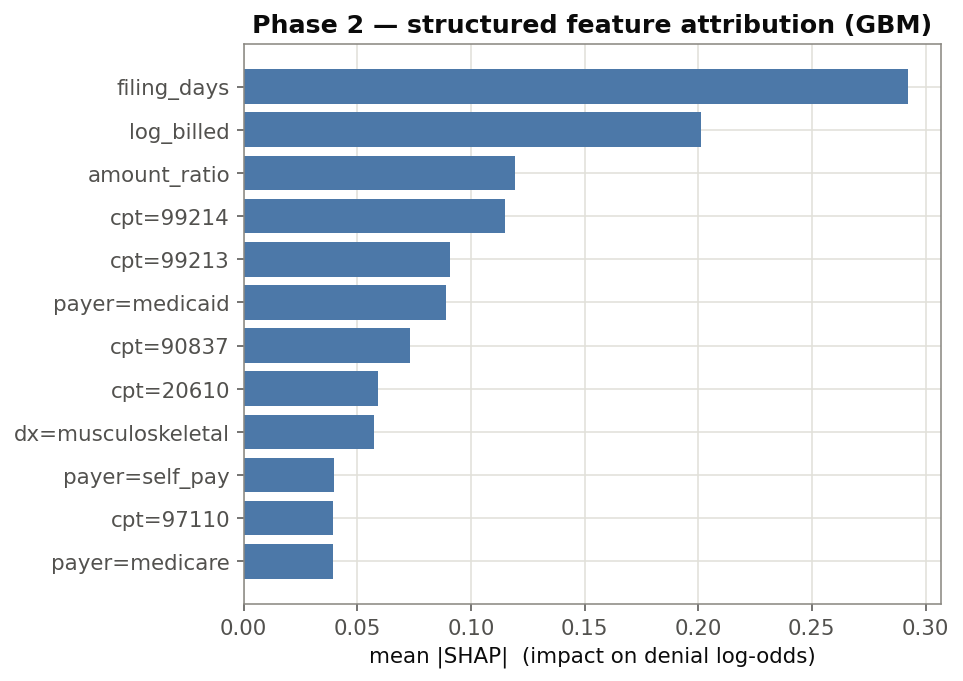


================ PHASE 2 SUMMARY ================
n_train=30000 n_test=10000 prevalence=0.229
model                    AUROC      F1       P       R
gradient_boosting       0.7343  0.3485  0.6194  0.2425
random_forest           0.7307  0.2417  0.6398  0.1490
top SHAP features (structured):
  filing_days                  0.2924
  log_billed                   0.2012
  amount_ratio                 0.1196
  cpt=99214                    0.1148
  cpt=99213                    0.0909
  payer=medicaid               0.0891
metrics -> artifacts/phase2/metrics.json  (shap_summary.png in figures/)


In [20]:
m2 = run_phase2(n=40_000, seed=42)
print_phase2_summary(m2)
import json as _json
with open(PHASE2_DIR / "metrics.json", "w") as f:
    _json.dump(m2, f, indent=2)
print(f"metrics -> {PHASE2_DIR / 'metrics.json'}  (shap_summary.png in figures/)")

## Run Phase 3

(TF-IDF encoder — fast, no heavy deps. The Claude zero-shot baseline is
intentionally not included; see the note above `run_phase3`.)

In [21]:
m3 = run_phase3(n=40_000, seed=42, encoder="tfidf")
print_phase3_summary(m3)
import json as _json
with open(PHASE3_DIR / "metrics.json", "w") as f:
    _json.dump(m3, f, indent=2)
print(f"metrics -> {PHASE3_DIR / 'metrics.json'}")


================ PHASE 3 SUMMARY ================
encoder=tfidf (dim=400)  n_train=30000 n_test=10000  test prevalence=0.229
model                            AUROC      F1       P       R
structured_only                 0.7323  0.4045  0.6042  0.3041
text_only                       0.6720  0.1138  0.5290  0.0638
structured_plus_text            0.7716  0.4249  0.6470  0.3163
structured_plus_blank_note      0.7319  0.4045  0.6077  0.3032
oracle_ceiling                  0.8827

text lift (fused - structured):   +0.0393  95% CI [+0.0296, +0.0490]  p(1-sided)=<0.0005
empty-note lift (guardrail ~0):   -0.0004
Brier: structured=0.1507  fused=0.1437
cost-optimal: t=0.08  $26.57/claim  saves $649,880 vs do-nothing
verdict: healthy — text lift bounded, statistically clear, guardrail clean
metrics -> artifacts/phase3/metrics.json


## Run Phase 4

Full run including the label-noise sweep (~2 min total). Pass `fast=True`
to skip the sweep if you just want the headline numbers quickly.

In [ ]:
art4 = run_phase4_full(fast=False)
print_phase4_summary(art4)

[1/6] training models (structured / retrieval-augmented / leaky)…


## Run the unified cross-phase ablation

The deliverable: one dataset, one split, the full ladder
`structured -> +text -> +retrieval -> +both`, each lift bootstrap-tested.

In [ ]:
m_ablation = run_unified_ablation(n=40_000, seed=42, k=10, encoder="tfidf")

---
All artifacts (metrics JSON + figures) are under `artifacts/` in the Colab
runtime's local filesystem. If you want to keep them after the runtime
recycles, zip and download, or mount Google Drive and copy `artifacts/`
there — e.g.:

```python
from google.colab import drive
drive.mount("/content/drive")
!cp -r artifacts /content/drive/MyDrive/claim_denial_artifacts
```